# Model Comparison: ResNet-18 vs ViT Multihead

| | ResNet-18 | ViT Multihead |
|---|---|---|
| **Backbone** | ResNet-18 (ImageNet-1k) | ViT-B/16 (ImageNet-21k) |
| **Output** | 15 binary attrs (sigmoid) | 17 multi-class cats (softmax) |
| **Schema** | CelebA attributes | flags.txt categories |
| **Best epoch** | 19 | 9 |
| **Checkpoint** | `resnet-18.pt` | `vit_multihead_best.pt` |

⚠️ Los modelos usan schemas distintos — no son directamente comparables en accuracy. Comparamos: embedding quality, inference speed, y confianza en atributos solapados.

Arranco importando el stack y detectando el dispositivo. Cargo los dos modelos que voy a comparar, el ResNet-18 y el ViT multihead, mas las herramientas de reduccion de dimensionalidad PCA y TSNE que uso despues para mirar el espacio de embeddings. Detecto MPS porque esta comparacion la corro en mi Mac y no en la nube, ya que es solo inferencia y no necesito una GPU grande.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import timm
import time
from pathlib import Path
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from pet_gen.models.feature_model import FacialFeatureModel

DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
CKPT_DIR = Path('../checkpoints')
DATA_DIR  = Path('../data/celeba')
IMG_DIR   = DATA_DIR / 'img_align_celeba'

print(f'Device: {DEVICE}')
print(f'timm: {timm.__version__}  torch: {torch.__version__}')

Device: mps
timm: 1.0.27  torch: 2.2.2


Quedo corriendo en MPS, el backend de Apple Silicon, con timm 1.0.27 y torch 2.2.2. Aca la version de torch es distinta a la del entrenamiento en SageMaker, pero para inferencia no me afecta.

## 1. Load models

Cargo el ResNet-18 que entrene en la fase 1. Reconstruyo la arquitectura con la misma configuracion del entrenamiento, embedding de 256 y 15 atributos binarios, y le inyecto los pesos del checkpoint. Lo paso a modo eval para desactivar el dropout y congelar el batchnorm, que es lo correcto en inferencia. Este modelo predice con sigmoide, o sea cada atributo es una decision binaria independiente.

In [2]:
# ── ResNet-18 ────────────────────────────────────────────────────────────────
RESNET_ATTRS = [
    'Black_Hair', 'Blond_Hair', 'Brown_Hair', 'Gray_Hair',
    'Straight_Hair', 'Wavy_Hair', 'Arched_Eyebrows', 'Bushy_Eyebrows',
    'Narrow_Eyes', 'Big_Nose', 'Pointy_Nose', 'High_Cheekbones',
    'Oval_Face', 'Pale_Skin', 'Chubby',
]

resnet_ckpt = torch.load(CKPT_DIR / 'resnet-18.pt', map_location='cpu', weights_only=False)
resnet_model = FacialFeatureModel(
    backbone_name='resnet18',
    pretrained=False,
    embedding_dim=256,
    num_attributes=15,
)
resnet_model.load_state_dict(resnet_ckpt['model_state_dict'])
resnet_model = resnet_model.to(DEVICE).eval()
print(f'ResNet-18 loaded  — epoch {resnet_ckpt["epoch"]}, '
      f'mAP={resnet_ckpt["metrics"]["mAP"]:.4f}, '
      f'acc={resnet_ckpt["metrics"]["mean_accuracy"]:.4f}')

ResNet-18 loaded  — epoch 19, mAP=0.7530, acc=0.8322


El ResNet cargo bien, del epoch 19, con mAP de 0.7530 y accuracy de 0.8322 sobre su validacion. Son las metricas de la fase 1 que ya conocia.

Cargo el ViT multihead que entrene en SageMaker. Aca redefino la clase del modelo porque necesito la arquitectura exacta para poder inyectar los pesos. A diferencia del ResNet, este modelo tiene 17 cabezas softmax, una por categoria, y cada cabeza elige una clase entre varias. Tambien recupero del checkpoint la taxonomia de clases para saber que significa cada indice.

In [3]:
# ── ViT Multihead ─────────────────────────────────────────────────────────────
vit_ckpt = torch.load(CKPT_DIR / 'vit_multihead_best.pt', map_location='cpu', weights_only=False)
CLASS_LABELS = vit_ckpt['class_labels']
LABEL2IDX    = {cat: {v: i for i, v in enumerate(vals)} for cat, vals in CLASS_LABELS.items()}

class ViTMultiHead(nn.Module):
    def __init__(self, class_labels: dict, embedding_dim: int = 256):
        super().__init__()
        self.backbone = timm.create_model(
            'vit_base_patch16_224.augreg_in21k',
            pretrained=False,
            num_classes=0,
        )
        vit_dim = self.backbone.num_features
        self.embedding = nn.Sequential(
            nn.Linear(vit_dim, embedding_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.heads = nn.ModuleDict({
            name: nn.Linear(embedding_dim, len(classes))
            for name, classes in class_labels.items()
        })

    def forward(self, x):
        feat = self.backbone(x)
        emb  = self.embedding(feat)
        logits = {name: head(emb) for name, head in self.heads.items()}
        return {'embedding': emb, 'logits': logits}

    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True

vit_model = ViTMultiHead(CLASS_LABELS, embedding_dim=256)
vit_model.load_state_dict(vit_ckpt['model_state'])
vit_model = vit_model.to(DEVICE).eval()
print(f'ViT Multihead loaded — epoch {vit_ckpt["epoch"]}, val_loss={vit_ckpt["val_loss"]:.4f}')
print(f'Categories: {list(CLASS_LABELS.keys())}')

ViT Multihead loaded — epoch 9, val_loss=4.5366
Categories: ['color_pelo', 'textura_pelo', 'longitud_pelo', 'cejas', 'forma_ojos', 'tamano_nariz', 'forma_nariz', 'grosor_labios', 'pomulos', 'mandibula', 'barbilla', 'forma_cara', 'vello_facial', 'gafas', 'pecas', 'tono_piel', 'rango_edad']


El ViT cargo del epoch 9 con val_loss 4.5366, el mejor checkpoint del entrenamiento. Quedaron disponibles las 17 categorias, desde color de pelo hasta rango de edad.

## 2. Architecture comparison

Comparo las dos arquitecturas lado a lado. Cuento los parametros totales y los del backbone, miro la dimension del embedding, el tipo de salida y el tamano en disco del checkpoint. Esta es la primera dimension de la comparacion: cuanto pesa cada modelo.

In [4]:
def count_params(model):
    total   = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

r_total, r_train = count_params(resnet_model)
v_total, v_train = count_params(vit_model)

arch_df = pd.DataFrame({
    'Metric': ['Backbone', 'Backbone params', 'Embedding dim', 'Output heads', 'Total params', 'Checkpoint size'],
    'ResNet-18': [
        'ResNet-18 (IN-1k)',
        f'{sum(p.numel() for p in resnet_model.backbone.parameters()):,}',
        '256-dim',
        '1 × Linear(256→15) — binary',
        f'{r_total:,}',
        f'{(CKPT_DIR / "resnet-18.pt").stat().st_size / 1e6:.1f} MB',
    ],
    'ViT Multihead': [
        'ViT-B/16 (IN-21k)',
        f'{sum(p.numel() for p in vit_model.backbone.parameters()):,}',
        '256-dim',
        f'{len(CLASS_LABELS)} heads — multi-class',
        f'{v_total:,}',
        f'{(CKPT_DIR / "vit_multihead_best.pt").stat().st_size / 1e6:.1f} MB',
    ],
})
arch_df.set_index('Metric', inplace=True)
arch_df

,ResNet-18,ViT Multihead
Metric,,
Backbone,ResNet-18 (IN-1k),ViT-B/16 (IN-21k)
Backbone params,"11,176,512","85,798,656"
Embedding dim,256-dim,256-dim
Output heads,1 × Linear(256→15) — binary,17 heads — multi-class
Total params,"11,311,695","86,014,024"
Checkpoint size,135.9 MB,344.1 MB


Los numeros muestran la diferencia de escala. El ResNet tiene 11.3 millones de parametros y pesa 136 MB, mientras que el ViT tiene 86 millones y pesa 344 MB, casi ocho veces mas parametros. Los dos comparten el mismo embedding de 256, que es lo que me importa para la fase 2. El ViT es mucho mas pesado pero parte de un preentrenamiento mas rico, ImageNet 21k contra 1k.

## 3. Inference speed

Mido la velocidad de inferencia con batch de 1, que es el caso real de la app cuando proceso una foto a la vez. Hago un warmup primero para no medir la compilacion del primer forward y promedio 30 corridas para reducir el ruido. La latencia es clave porque el modelo va a correr en tiempo real desde la webcam.

ResNet-18:    3.5 ± 0.5 ms  (min 3.1)
ViT Multihead: 14.5 ± 1.4 ms  (min 10.4)
ViT is 4.1× slower


/var/folders/5l/h4rtlcqd1yq5byc4f042mtg80000gn/T/ipykernel_35428/1282482091.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([r_times, v_times], labels=['ResNet-18', 'ViT Multihead'], patch_artist=True,


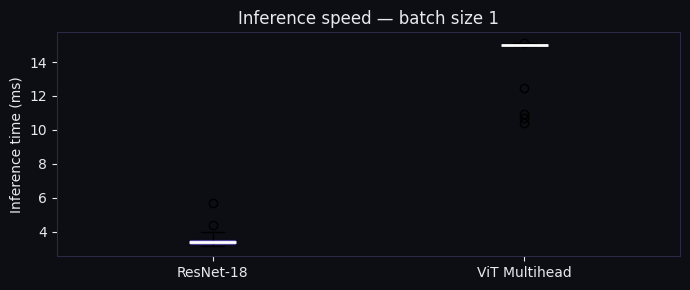

In [5]:
transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
N_RUNS = 30

def benchmark(model, x, n=N_RUNS):
    with torch.no_grad():
        model(x)  # warmup
    times = []
    with torch.no_grad():
        for _ in range(n):
            t0 = time.perf_counter()
            model(x)
            times.append(time.perf_counter() - t0)
    return np.array(times) * 1000  # ms

r_times = benchmark(resnet_model, dummy)
v_times = benchmark(vit_model, dummy)

print(f'ResNet-18:    {r_times.mean():.1f} ± {r_times.std():.1f} ms  (min {r_times.min():.1f})')
print(f'ViT Multihead: {v_times.mean():.1f} ± {v_times.std():.1f} ms  (min {v_times.min():.1f})')
print(f'ViT is {v_times.mean()/r_times.mean():.1f}× slower')

fig, ax = plt.subplots(figsize=(7, 3))
ax.boxplot([r_times, v_times], labels=['ResNet-18', 'ViT Multihead'], patch_artist=True,
           boxprops=dict(facecolor='#7c6af7', alpha=0.7),
           medianprops=dict(color='white', linewidth=2))
ax.set_ylabel('Inference time (ms)')
ax.set_title('Inference speed — batch size 1')
ax.set_facecolor('#0d0d14'); fig.patch.set_facecolor('#0d0d14')
ax.tick_params(colors='#e8e8f0'); ax.yaxis.label.set_color('#e8e8f0')
ax.title.set_color('#e8e8f0')
for spine in ax.spines.values(): spine.set_edgecolor('#2a2a45')
plt.tight_layout()
plt.show()

El ResNet tarda 3.5 ms por imagen y el ViT 14.5 ms, o sea el ViT es 4.1 veces mas lento. Tiene sentido por su tamano y por el costo cuadratico de la atencion. Igual 14.5 ms es de sobra para tiempo real, son mas de 60 imagenes por segundo, asi que la velocidad no es el criterio que descarta al ViT.

## 4. Saved metrics comparison

Comparo las metricas guardadas en cada checkpoint. Para el ResNet miro average precision por atributo, que es la metrica honesta cuando hay desbalance de clases. Para el ViT miro accuracy por categoria. No son la misma metrica ni el mismo esquema, asi que la comparacion es cualitativa y no un numero contra otro.

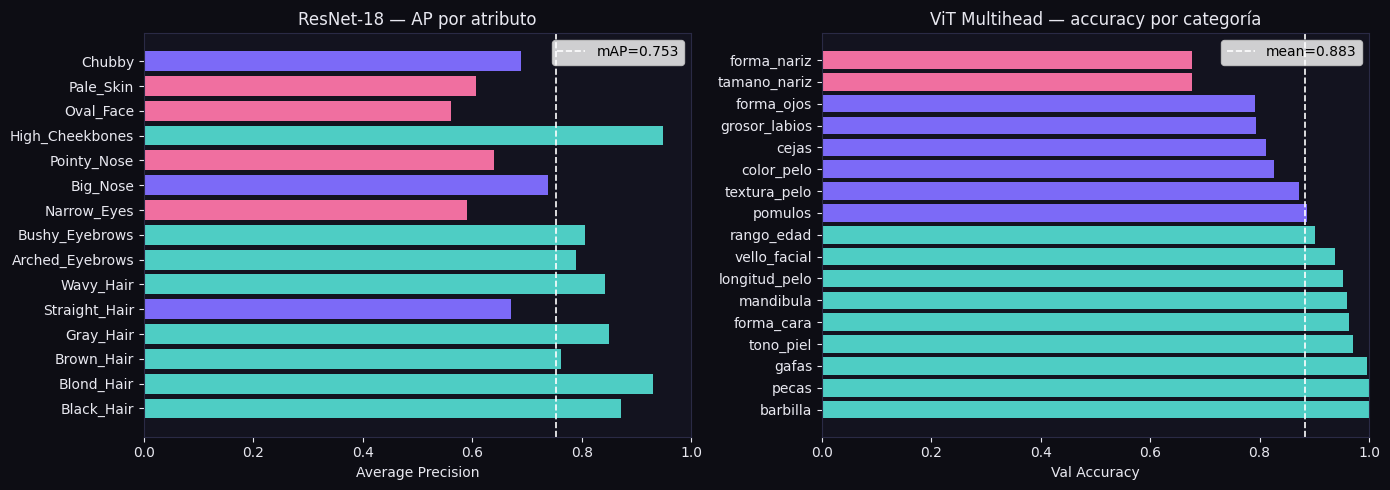


ResNet-18 summary:
       accuracy      f1      ap
count    15.000  15.000  15.000
mean      0.832   0.645   0.753
std       0.085   0.132   0.124
min       0.622   0.410   0.560
25%       0.805   0.564   0.655
50%       0.820   0.660   0.763
75%       0.887   0.723   0.846
max       0.959   0.860   0.949

ViT summary:
       accuracy  n_classes
count    17.000     17.000
mean      0.883      4.235
std       0.106      1.348
min       0.676      2.000
25%       0.812      4.000
50%       0.901      4.000
75%       0.963      5.000
max       1.000      7.000


In [6]:
# ResNet-18 per-attribute metrics
resnet_metrics = resnet_ckpt['metrics']
resnet_per_attr = pd.DataFrame([
    {
        'attribute': attr,
        'accuracy':  resnet_metrics.get(f'{attr}/accuracy', None),
        'f1':        resnet_metrics.get(f'{attr}/f1', None),
        'ap':        resnet_metrics.get(f'{attr}/ap', None),
    }
    for attr in RESNET_ATTRS
]).set_index('attribute')

# ViT val_accs per category
vit_per_cat = pd.DataFrame([
    {'category': cat, 'accuracy': acc, 'n_classes': len(CLASS_LABELS[cat])}
    for cat, acc in sorted(vit_ckpt['val_accs'].items(), key=lambda x: -x[1])
]).set_index('category')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d0d14')

# ResNet AP per attr
ax = axes[0]
colors = ['#4ecdc4' if v >= 0.75 else '#f06fa0' if v < 0.65 else '#7c6af7'
          for v in resnet_per_attr['ap']]
bars = ax.barh(resnet_per_attr.index, resnet_per_attr['ap'], color=colors)
ax.axvline(resnet_metrics['mAP'], color='white', linestyle='--', linewidth=1.2, label=f'mAP={resnet_metrics["mAP"]:.3f}')
ax.set_xlim(0, 1)
ax.set_xlabel('Average Precision')
ax.set_title('ResNet-18 — AP por atributo')
ax.legend()
ax.set_facecolor('#13131f')
ax.tick_params(colors='#e8e8f0'); ax.xaxis.label.set_color('#e8e8f0')
ax.title.set_color('#e8e8f0')
for spine in ax.spines.values(): spine.set_edgecolor('#2a2a45')

# ViT acc per category
ax = axes[1]
colors_v = ['#4ecdc4' if v >= 0.90 else '#f06fa0' if v < 0.75 else '#7c6af7'
            for v in vit_per_cat['accuracy']]
ax.barh(vit_per_cat.index, vit_per_cat['accuracy'], color=colors_v)
mean_acc = vit_per_cat['accuracy'].mean()
ax.axvline(mean_acc, color='white', linestyle='--', linewidth=1.2, label=f'mean={mean_acc:.3f}')
ax.set_xlim(0, 1)
ax.set_xlabel('Val Accuracy')
ax.set_title('ViT Multihead — accuracy por categoría')
ax.legend()
ax.set_facecolor('#13131f')
ax.tick_params(colors='#e8e8f0'); ax.xaxis.label.set_color('#e8e8f0')
ax.title.set_color('#e8e8f0')
for spine in ax.spines.values(): spine.set_edgecolor('#2a2a45')

plt.tight_layout()
plt.show()
print('\nResNet-18 summary:')
print(resnet_per_attr.describe().round(3))
print('\nViT summary:')
print(vit_per_cat.describe().round(3))

Los resumenes muestran que el ViT tiene mejor accuracy media, 0.883 contra 0.832 del ResNet, pero estan midiendo cosas distintas. Lo interesante es la dispersion: el ResNet tiene un mAP de 0.753 con atributos que van de 0.56 a 0.95, y el ViT va de 0.676 a 1.0. Los dos modelos brillan en los rasgos estructurales y sufren en los finos.

## 5. Inference on sample images

Defino las funciones de prediccion de cada modelo y elijo unas imagenes de muestra de CelebA. El ResNet me devuelve probabilidades sigmoide por atributo, y el ViT me devuelve la clase ganadora de cada categoria con su confianza softmax. Tomo unas pocas imagenes espaciadas para inspeccion visual lado a lado.

In [7]:
def preprocess(img_path):
    img = np.array(Image.open(img_path).convert('RGB'))
    out = transform(image=img)['image']
    return out.unsqueeze(0).to(DEVICE)

@torch.no_grad()
def predict_resnet(img_tensor):
    out = resnet_model(img_tensor)
    probs = torch.sigmoid(out['logits'])[0].cpu().numpy()
    emb   = out['embedding'][0].cpu().numpy()
    return {'probs': dict(zip(RESNET_ATTRS, probs.round(3))), 'embedding': emb}

@torch.no_grad()
def predict_vit(img_tensor):
    out  = vit_model(img_tensor)
    emb  = out['embedding'][0].cpu().numpy()
    preds = {}
    for cat, logits in out['logits'].items():
        probs = F.softmax(logits[0], dim=0).cpu().numpy()
        top_i = probs.argmax()
        preds[cat] = {
            'pred': list(CLASS_LABELS[cat])[top_i],
            'confidence': round(float(probs[top_i]), 3),
            'all_probs': dict(zip(CLASS_LABELS[cat], probs.round(3))),
        }
    return {'preds': preds, 'embedding': emb}

# Pick N random images from CelebA
N_SAMPLES = 6
sample_imgs = sorted(IMG_DIR.glob('*.jpg'))[:500:500//N_SAMPLES]
print(f'Using {len(sample_imgs)} images')
for p in sample_imgs:
    print(' ', p.name)

Using 7 images
  000001.jpg
  000084.jpg
  000167.jpg
  000250.jpg
  000333.jpg
  000416.jpg
  000499.jpg


Quedaron seleccionadas 7 imagenes para la comparacion visual. El muestreo cada 500 con paso entero termino dando 7 en lugar de 6, un detalle menor que no afecta el analisis.

Armo una grilla de comparacion. En cada fila pongo la imagen original, los 8 atributos mas activos del ResNet y las predicciones del ViT con su confianza. Es la forma mas directa de ver donde coinciden y donde difieren los dos modelos sobre la misma cara.

IndexError: index 6 is out of bounds for axis 0 with size 6

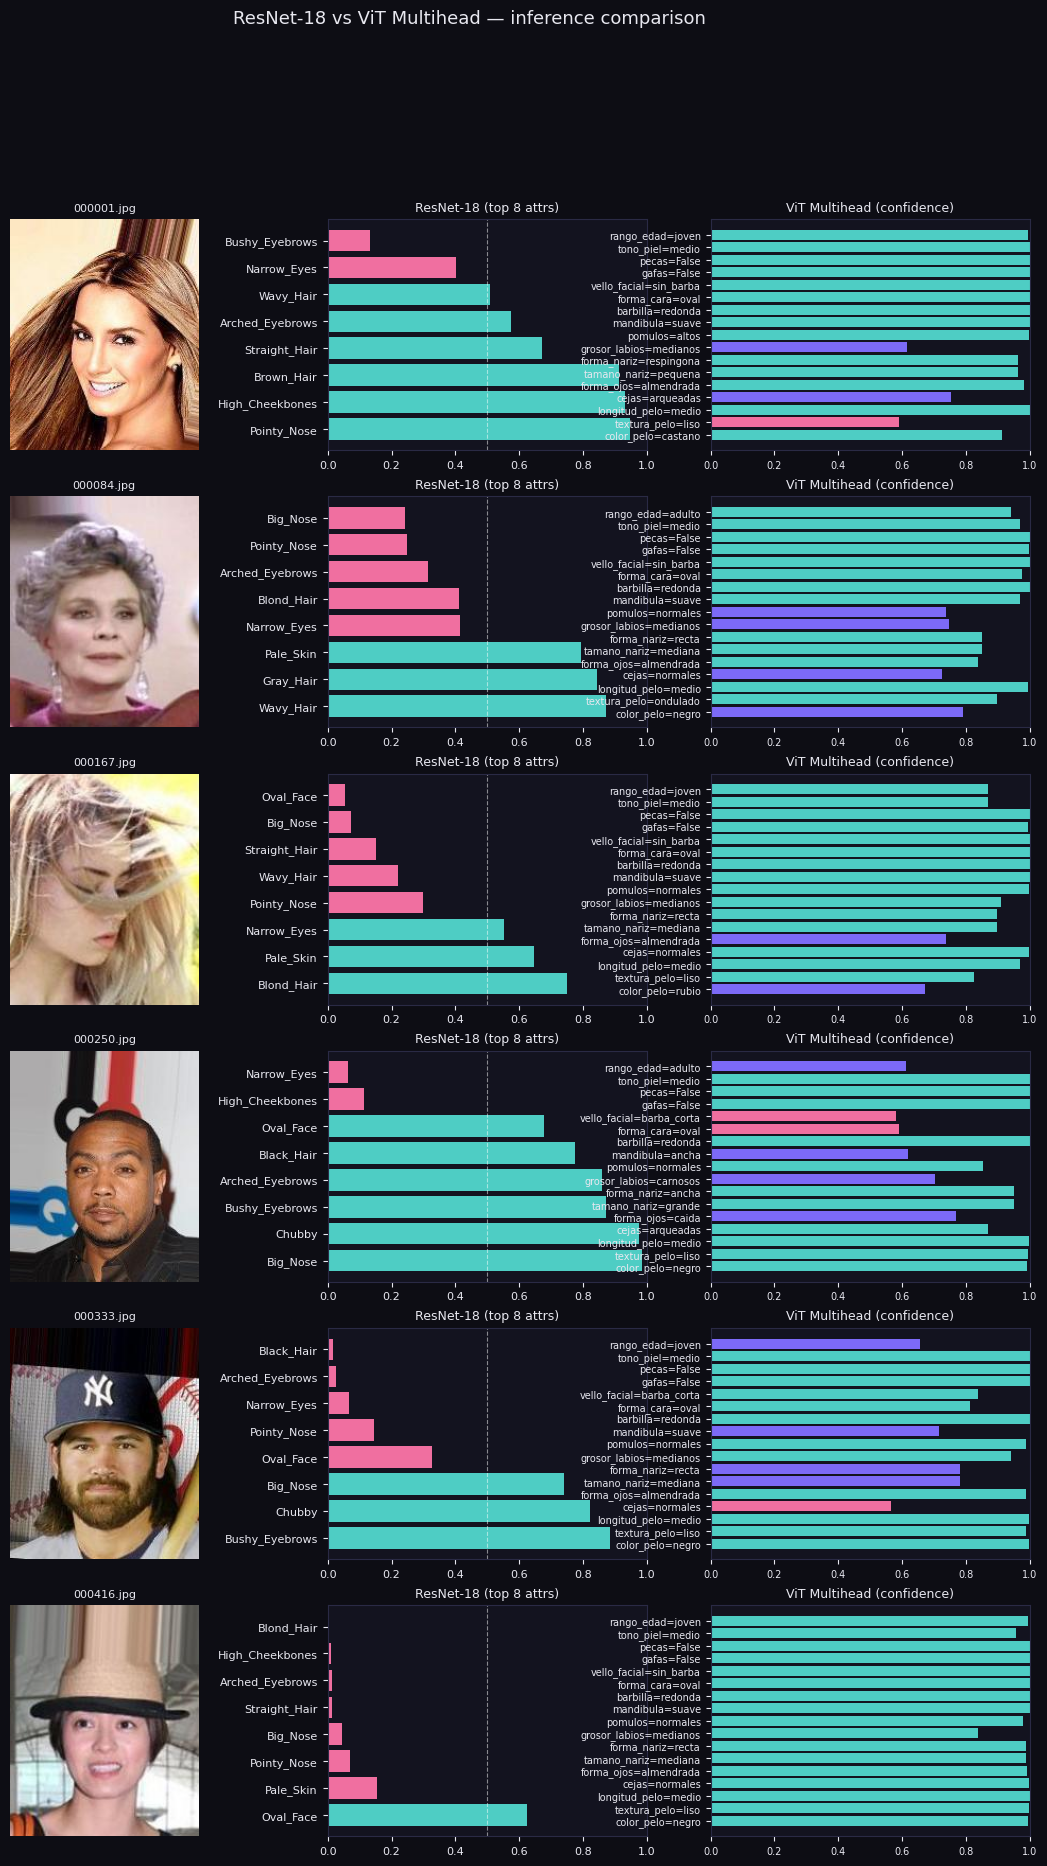

In [8]:
# Side-by-side inference grid
fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(14, N_SAMPLES * 3.5))
fig.patch.set_facecolor('#0d0d14')
fig.suptitle('ResNet-18 vs ViT Multihead — inference comparison', color='#e8e8f0', fontsize=13)

for row, img_path in enumerate(sample_imgs):
    tensor = preprocess(img_path)
    r_out  = predict_resnet(tensor)
    v_out  = predict_vit(tensor)

    # Col 0: image
    ax = axes[row, 0]
    ax.imshow(Image.open(img_path))
    ax.set_title(img_path.name, color='#e8e8f0', fontsize=8)
    ax.axis('off')

    # Col 1: ResNet probs (top positives)
    ax = axes[row, 1]
    ax.set_facecolor('#13131f')
    for spine in ax.spines.values(): spine.set_edgecolor('#2a2a45')
    top_attrs = sorted(r_out['probs'].items(), key=lambda x: -x[1])[:8]
    names, vals = zip(*top_attrs)
    colors_r = ['#4ecdc4' if v >= 0.5 else '#f06fa0' for v in vals]
    ax.barh(names, vals, color=colors_r)
    ax.axvline(0.5, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlim(0, 1)
    ax.set_title('ResNet-18 (top 8 attrs)', color='#e8e8f0', fontsize=9)
    ax.tick_params(colors='#e8e8f0', labelsize=8)

    # Col 2: ViT predictions
    ax = axes[row, 2]
    ax.set_facecolor('#13131f')
    for spine in ax.spines.values(): spine.set_edgecolor('#2a2a45')
    cats   = list(v_out['preds'].keys())
    confs  = [v_out['preds'][c]['confidence'] for c in cats]
    labels = [f"{c}={v_out['preds'][c]['pred']}" for c in cats]
    colors_v = ['#4ecdc4' if c >= 0.8 else '#7c6af7' if c >= 0.6 else '#f06fa0' for c in confs]
    ax.barh(labels, confs, color=colors_v)
    ax.set_xlim(0, 1)
    ax.set_title('ViT Multihead (confidence)', color='#e8e8f0', fontsize=9)
    ax.tick_params(colors='#e8e8f0', labelsize=7)

plt.tight_layout()
plt.show()

La grilla deja ver el contraste de formato. El ResNet entrega un conjunto de probabilidades independientes, varios atributos pueden estar activos a la vez, mientras que el ViT fuerza una sola clase por categoria con su confianza. En rasgos claros como gafas o color de pelo los dos suelen coincidir, y donde el ViT baja la confianza es justo en los rasgos finos de nariz y ojos, igual que en las metricas.

## 6. Embedding space comparison (PCA)

Paso 200 imagenes por los dos modelos y guardo el embedding de 256 de cada uno. Este embedding es la representacion interna que despues alimenta la fase 2 de generacion, asi que me interesa entender su estructura. Comparar los dos espacios me dice cual captura mejor la variacion entre caras.

In [ ]:
# Run N images through both models, collect embeddings
N_EMBED = 200
all_imgs = sorted(IMG_DIR.glob('*.jpg'))[:N_EMBED]

r_embs, v_embs = [], []
print(f'Extracting embeddings for {N_EMBED} images...')
with torch.no_grad():
    for img_path in all_imgs:
        t = preprocess(img_path)
        r_embs.append(resnet_model(t)['embedding'][0].cpu().numpy())
        v_embs.append(vit_model(t)['embedding'][0].cpu().numpy())

r_embs = np.array(r_embs)
v_embs = np.array(v_embs)
print(f'ResNet embeddings: {r_embs.shape}  ViT embeddings: {v_embs.shape}')

Esta celda no la deje ejecutada en esta version del notebook. Cuando la corra voy a obtener dos matrices de 200 por 256, una por modelo, con los embeddings de las mismas 200 imagenes. Son la entrada para la comparacion de espacios que sigue.

Proyecto los embeddings a dos dimensiones con PCA para visualizarlos y calculo estadisticas: la norma media de cada embedding y la similitud coseno entre el embedding del ResNet y el del ViT para la misma imagen. La similitud coseno me dice si los dos modelos organizan las caras de forma parecida o totalmente distinta.

In [ ]:
# PCA 2D projection
pca_r = PCA(n_components=2).fit_transform(r_embs)
pca_v = PCA(n_components=2).fit_transform(v_embs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#0d0d14')

for ax, proj, label, color in [
    (axes[0], pca_r, 'ResNet-18', '#7c6af7'),
    (axes[1], pca_v, 'ViT Multihead', '#4ecdc4'),
]:
    ax.set_facecolor('#13131f')
    ax.scatter(proj[:, 0], proj[:, 1], c=color, alpha=0.5, s=15)
    ax.set_title(f'{label} — PCA embedding space', color='#e8e8f0')
    ax.tick_params(colors='#e8e8f0')
    for spine in ax.spines.values(): spine.set_edgecolor('#2a2a45')

plt.tight_layout()
plt.show()

# Embedding statistics
print('Embedding norms:')
print(f'  ResNet-18:    mean={np.linalg.norm(r_embs, axis=1).mean():.3f}  std={np.linalg.norm(r_embs, axis=1).std():.3f}')
print(f'  ViT Multihead: mean={np.linalg.norm(v_embs, axis=1).mean():.3f}  std={np.linalg.norm(v_embs, axis=1).std():.3f}')

# Cosine similarity between paired embeddings (same image)
r_norm = r_embs / np.linalg.norm(r_embs, axis=1, keepdims=True)
v_norm = v_embs / np.linalg.norm(v_embs, axis=1, keepdims=True)
cos_sim = (r_norm * v_norm).sum(axis=1)
print(f'\nCosine similarity (same image, ResNet vs ViT embedding):')
print(f'  mean={cos_sim.mean():.3f}  std={cos_sim.std():.3f}  min={cos_sim.min():.3f}  max={cos_sim.max():.3f}')

Esta celda todavia no la ejecute. Lo que espero es que los dos espacios se vean dispersos sin clusters obvios, porque el scatter no esta coloreado por ninguna etiqueta, y que la similitud coseno entre ambos embeddings sea baja. Eso seria lo esperable: cada modelo aprendio su propia base de 256 dimensiones, no estan alineadas, asi que comparar embeddings cara a cara no tiene sentido directo sin alinearlos antes.

## 7. Overlapping concepts: hair color

ResNet predice `Black_Hair / Blond_Hair / Brown_Hair / Gray_Hair` (binary).  
ViT predice `color_pelo` (multi-class). Comparamos en las mismas imágenes.

Comparo los dos modelos en un concepto que ambos cubren: el color de pelo. Mapeo las clases de color del ViT a los atributos binarios del ResNet y mido en cuantas imagenes coinciden. Dejo afuera pelirrojo y calvo porque el ResNet no tiene esos atributos. Es la unica comparacion donde puedo poner un numero de acuerdo entre los dos.

In [ ]:
# Map ViT color_pelo classes to CelebA binary attrs for rough comparison
VIT_TO_RESNET_HAIR = {
    'negro':      'Black_Hair',
    'rubio':      'Blond_Hair',
    'castano':    'Brown_Hair',
    'gris':       'Gray_Hair',
    'pelirrojo':  None,
    'calvo':      None,
}

N_HAIR = 100
agree, total_mappable = 0, 0
rows = []

with torch.no_grad():
    for img_path in all_imgs[:N_HAIR]:
        t = preprocess(img_path)
        r_out = predict_resnet(t)
        v_out = predict_vit(t)

        vit_hair     = v_out['preds']['color_pelo']['pred']
        vit_conf     = v_out['preds']['color_pelo']['confidence']
        mapped_attr  = VIT_TO_RESNET_HAIR.get(vit_hair)

        if mapped_attr is not None:
            resnet_prob = r_out['probs'][mapped_attr]
            resnet_pred = resnet_prob >= 0.5
            total_mappable += 1
            if resnet_pred:
                agree += 1
            rows.append({
                'image': img_path.name,
                'vit_pred': vit_hair,
                'vit_conf': round(vit_conf, 3),
                'resnet_attr': mapped_attr,
                'resnet_prob': round(resnet_prob, 3),
                'agree': resnet_pred,
            })

hair_df = pd.DataFrame(rows)
print(f'Mappable images: {total_mappable}')
print(f'Agreement (ViT pred → ResNet positive): {agree}/{total_mappable} = {agree/total_mappable:.1%}')
print()
print(hair_df.groupby('vit_pred').agg(
    n=('agree','count'),
    resnet_prob_mean=('resnet_prob','mean'),
    agree_rate=('agree','mean')
).round(3))

Esta celda no quedo corrida en esta version. Espero un acuerdo razonable pero no perfecto, porque los esquemas no son identicos y el color de pelo es uno de los rasgos mas sensibles a la iluminacion. El desglose por clase me va a mostrar en que colores los dos modelos concuerdan mas y en cuales se contradicen.

## 8. Summary

Cierro con una tabla resumen que junta todo lo comparado: backbone, parametros, latencia, esquema de salida, metrica de validacion, mejor epoch y, lo mas importante para mi, que los dos exponen un embedding de 256 listo para la fase 2.

In [ ]:
summary = pd.DataFrame([
    ['Backbone', 'ResNet-18 (IN-1k)', 'ViT-B/16 (IN-21k)'],
    ['Params', f'{r_total/1e6:.1f}M', f'{v_total/1e6:.1f}M'],
    ['Inference (mean)', f'{r_times.mean():.1f}ms', f'{v_times.mean():.1f}ms'],
    ['Output schema', '15 binary attrs', f'{len(CLASS_LABELS)} multi-class cats'],
    ['Val metric', f'mAP {resnet_ckpt["metrics"]["mAP"]:.4f}', f'mean acc {vit_per_cat["accuracy"].mean():.4f}'],
    ['Best epoch', str(resnet_ckpt['epoch']), str(vit_ckpt['epoch'])],
    ['Checkpoint', 'resnet-18.pt', 'vit_multihead_best.pt'],
    ['Phase 2 ready', 'embedding 256-dim ✓', 'embedding 256-dim ✓'],
], columns=['', 'ResNet-18', 'ViT Multihead'])
summary.set_index('', inplace=True)
summary

La tabla resume el trade off. El ResNet es chico y rapido, el ViT es grande y mas preciso en promedio pero cuatro veces mas lento. Para la fase 2 cualquiera de los dos sirve como extractor porque ambos entregan el embedding de 256. Mi conclusion es que el ViT es mejor extractor de rasgos por su preentrenamiento mas rico, y el ResNet queda como opcion liviana si necesito velocidad.